# Local MIMIC-IV Hypotension POC: Importance Clusters And Value Heatmaps

This notebook trains one small ViT proof-of-concept model, evaluates it, generates model explanations, clusters patients by those importance maps, and plots mean clinical values for each cluster.

Heatmap semantics:

- color = mean observed clinical value, with blue for low and red for high
- opacity or border width = mean model importance
- gray = no observed values for that variable/time cell
- optional importance threshold = emphasize only the top-importance cells
- colorbar tick numbers are hidden because rows can have different clinical units

## 1. Project Paths And Imports

Run this notebook either from the repository root or from the `notebooks/` directory.

In [1]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
PROJECT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd
SRC_DIR = PROJECT_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

RECORDS_PATH = PROJECT_DIR / 'data' / 'mimic_hypotension' / 'records.csv'
LABELS_PATH = PROJECT_DIR / 'data' / 'mimic_hypotension' / 'labels.csv'

print('PROJECT_DIR:', PROJECT_DIR)
print('RECORDS_PATH:', RECORDS_PATH, RECORDS_PATH.exists())
print('LABELS_PATH:', LABELS_PATH, LABELS_PATH.exists())

if not RECORDS_PATH.exists() or not LABELS_PATH.exists():
    raise FileNotFoundError('Expected records.csv and labels.csv under data/mimic_hypotension/.')

os.chdir(PROJECT_DIR)

PROJECT_DIR: /home/michalwe/Interpretable-ViT-for-Timeseries
RECORDS_PATH: /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_hypotension/records.csv True
LABELS_PATH: /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_hypotension/labels.csv True


## 2. Runtime Check

This uses the local Python environment. If an import fails, install dependencies with `pip install -r requirements.txt` and restart the kernel.

In [2]:
import numpy as np
import pandas as pd
import torch

import interpretable_ts_vit

print('interpretable_ts_vit:', interpretable_ts_vit)
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')

interpretable_ts_vit: <module 'interpretable_ts_vit' from '/home/michalwe/Interpretable-ViT-for-Timeseries/src/interpretable_ts_vit/__init__.py'>
torch: 2.6.0+cu124
cuda available: True
device: NVIDIA GeForce RTX 3090


## 3. Create A Small Balanced Local POC Dataset

This notebook is configured to use the full prepared MIMIC records and labels. Set `USE_SUBSET = True` only when you want a quick local smoke test.

In [3]:
USE_SUBSET = False
PATIENTS_PER_CLASS = 120
RANDOM_STATE = 13

POC_DATA_DIR = PROJECT_DIR / 'data' / 'mimic_hypotension_local_poc'
POC_DATA_DIR.mkdir(parents=True, exist_ok=True)
POC_RECORDS_PATH = POC_DATA_DIR / 'records.csv'
POC_LABELS_PATH = POC_DATA_DIR / 'labels.csv'

if USE_SUBSET:
    labels = pd.read_csv(LABELS_PATH)
    counts = labels['label'].value_counts()
    per_class = min(PATIENTS_PER_CLASS, int(counts.min()))
    sampled_labels = (
        labels.groupby('label', group_keys=False)
        .sample(n=per_class, random_state=RANDOM_STATE)
        .sort_values('patient_id')
    )
    sampled_ids = set(sampled_labels['patient_id'].astype(str))
    sampled_labels.to_csv(POC_LABELS_PATH, index=False)

    first = True
    kept_records = 0
    for chunk in pd.read_csv(RECORDS_PATH, chunksize=500_000, dtype={'patient_id': str}):
        selected = chunk[chunk['patient_id'].isin(sampled_ids)]
        if len(selected):
            selected.to_csv(POC_RECORDS_PATH, index=False, mode='w' if first else 'a', header=first)
            first = False
            kept_records += len(selected)
    if first:
        pd.DataFrame(columns=['patient_id', 'variable', 'value', 'timestamp']).to_csv(POC_RECORDS_PATH, index=False)

    active_records_path = POC_RECORDS_PATH
    active_labels_path = POC_LABELS_PATH
    print(f'Created local POC subset: {len(sampled_labels)} patients, {kept_records} records')
else:
    active_records_path = RECORDS_PATH
    active_labels_path = LABELS_PATH

print('Active records:', active_records_path)
print('Active labels:', active_labels_path)
display(pd.read_csv(active_labels_path)['label'].value_counts().rename('count'))


Active records: /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_hypotension/records.csv
Active labels: /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_hypotension/labels.csv


label
False    36100
True     27271
Name: count, dtype: int64

## 4. Configure Pipeline Stages

Edit the config here, then run only the stage cells you need below. Use `RESET_OUTPUTS = True` only when you intentionally want to delete prior tensors, model checkpoints, metrics, explanations, and plots. Set `LOAD_SAVED_MODEL = True` to reuse an existing checkpoint at `SAVED_MODEL_PATH` instead of training a new model.

In [ ]:
import shutil

from interpretable_ts_vit.config import DataConfig, ModelConfig, TrainConfig, ExplainConfig, ClusterConfig
from interpretable_ts_vit.data_modules import MIMICHypotensionDataModule
from interpretable_ts_vit.model_modules import ViTTimeSeriesModule

RUN_DIR = PROJECT_DIR / 'runs' / 'full_hypotension_importance_values'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed_full_hypotension_importance_values'
SPLIT = 'test'

# Set True only when you intentionally want to delete prior tensors/model/results.
RESET_OUTPUTS = False
LOAD_SAVED_MODEL = True
SAVED_MODEL_PATH = RUN_DIR / 'model.pt'

if RESET_OUTPUTS:
    shutil.rmtree(RUN_DIR, ignore_errors=True)
    shutil.rmtree(PROCESSED_DIR, ignore_errors=True)

CLUSTER_FEATURE_MODE = 'vit_embedding'  # 'vit_embedding', 'explanation', 'value', or 'combined'
IMPORTANCE_PLOT_MODE = 'value_with_importance_opacity'  # or 'value_with_importance_border'
IMPORTANCE_THRESHOLD = 0.8  # e.g. 0.8 emphasizes only the top 20% most important cells
SHOW_MEAN_VALUES = False  # set True to print the mean value inside each heatmap cell
USE_NORMAL_RANGES = True  # color values as low / normal / high using src/interpretable_ts_vit/normal_ranges.json

data_config = DataConfig(
    granularity='0.5h',
    aggregation='mean',
    val_fraction=0.2,
    test_fraction=0.2,
    random_state=RANDOM_STATE,
)
model_config = ModelConfig(
    patch_size=(1, 4),
    embed_dim=64,
    depth=2,
    num_heads=4,
    mlp_ratio=2.0,
    dropout=0.1,
)
train_config = TrainConfig(
    batch_size=64,
    epochs=50,
    learning_rate=1e-3,
    weight_decay=1e-4,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    early_stopping_patience=8,
    early_stopping_monitor='val_loss',
    restore_best_model=True,
)
train_config.verbose = True
train_config.progress_interval_batches = 25
explain_config = ExplainConfig(method='transformer_attribution', target_class=1)
cluster_config = ClusterConfig(
    method='kmeans',
    n_clusters=4,
    feature_mode=CLUSTER_FEATURE_MODE,
    explanation_weight=1.0,
    value_weight=0.75,
    hdbscan_min_cluster_size=20,
    hdbscan_min_samples=None,
    plot_mode=IMPORTANCE_PLOT_MODE,
    importance_threshold=IMPORTANCE_THRESHOLD,
    show_values=SHOW_MEAN_VALUES,
    use_normal_ranges=USE_NORMAL_RANGES,
)

data = MIMICHypotensionDataModule(
    records_path=active_records_path,
    labels_path=active_labels_path,
    processed_dir=PROCESSED_DIR,
    data_config=data_config,
)

model = ViTTimeSeriesModule(
    run_dir=RUN_DIR,
    model_config=model_config,
    train_config=train_config,
    explain_config=explain_config,
    cluster_config=cluster_config,
)

print('Configured paths:')
print('  processed:', data.processed_dir)
print('  run:', model.run_dir)
print('  split:', SPLIT)




Configured paths:
  processed: /home/michalwe/Interpretable-ViT-for-Timeseries/data/processed_full_hypotension_importance_values
  run: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values
  split: test


## What Can Be Changed Without Retraining

After the model is trained, you can rerun later cells with different evaluation, explanation, clustering, or plotting settings without rerunning training.

Safe to change after training:

- `SPLIT`, then rerun evaluation/explanation/visualization for that split.
- `model.train_config.batch_size` or `model.train_config.device` for evaluation/explanation runtime behavior.
- `model.explain_config.method` or `model.explain_config.target_class`, then rerun **Generate Explanations** and **Cluster And Plot Value Heatmaps**.
- `model.cluster_config.method`, `feature_mode`, `explanation_weight`, `value_weight`, `n_clusters` for k-means, or `hdbscan_min_cluster_size` / `hdbscan_min_samples` for HDBSCAN, then rerun **Cluster And Plot Value Heatmaps**.
- `model.cluster_config.plot_mode`, `importance_threshold`, or `show_values`, then rerun **Cluster And Plot Value Heatmaps**.
- Plot color/style changes in `visualization.py`, then rerun **Cluster And Plot Value Heatmaps**.

Requires earlier stages:

- Changing `data_config` values such as granularity, time range, split fractions, or aggregation requires rerunning **Prepare Tensor Splits** and all later stages.
- Changing `model_config` values such as patch size, embedding size, depth, heads, or dropout requires rerunning **Train Model** and all later stages.
- Changing training settings such as epochs, learning rate, weight decay, or early stopping requires rerunning **Train Model** and all later stages.

Note: evaluation currently reuses `TrainConfig` for runtime settings like `device` and `batch_size`; those can be changed after training because they do not alter the saved model weights.


## 5. Prepare Tensor Splits

Run this when you change data binning/split settings or input records. You do not need to rerun it for training-only, explanation-only, or plot-only experiments.

In [5]:
data.prepare()
data.load()

print('Prepared tensors:')
print('  processed_dir:', data.processed_dir)
print('  variables:', data.variable_vocab)
print('  labels:', data.label_names)


Prepared tensors:
  processed_dir: /home/michalwe/Interpretable-ViT-for-Timeseries/data/processed_full_hypotension_importance_values
  variables: ['creatinine', 'diastolic_bp', 'glucose', 'heart_rate', 'lactate', 'mean_bp', 'respiratory_rate', 'spo2', 'systolic_bp', 'temperature']
  labels: ['False', 'True']


## 6. Train Model

Run this when you change model or training config. It reuses the prepared tensors and either loads an existing checkpoint from `SAVED_MODEL_PATH` or trains a new model and writes artifacts under `RUN_DIR`.

In [12]:
if LOAD_SAVED_MODEL and SAVED_MODEL_PATH.exists():
    print(f'Loading saved model from {SAVED_MODEL_PATH}')
    train_metrics = {'loaded_from': str(SAVED_MODEL_PATH), 'status': 'loaded'}
elif LOAD_SAVED_MODEL:
    print(f'{SAVED_MODEL_PATH} not found; training a new model instead.')
    train_metrics = model.fit(data)
else:
    train_metrics = model.fit(data)

print('Training artifacts:')
print('  run_dir:', model.run_dir)
print()
print('Train metrics:', train_metrics)


Loading saved model from /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/model.pt
Training artifacts:
  run_dir: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values

Train metrics: {'loaded_from': '/home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/model.pt', 'status': 'loaded'}


## 7. Evaluate Model

Run this after training, or rerun it whenever you want fresh metrics/predictions for the selected split.

In [13]:
evaluation_metrics = model.evaluate(data, split=SPLIT)

print('Evaluation artifacts:')
print('  metrics:', model.metrics_path(SPLIT))
print('  predictions:', model.predictions_path(SPLIT))
print()
print('Evaluation metrics:', evaluation_metrics)


Evaluation artifacts:
  metrics: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/test_evaluation_metrics.json
  predictions: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/test_predictions.csv

Evaluation metrics: {'accuracy': 0.7659171597633136, 'macro_f1': 0.7617918866522677, 'confusion_matrix': [[5688, 1532], [1435, 4020]], 'auroc': 0.8449601245140927}


## 8. Generate Explanations

Run this after training. If you change `ExplainConfig`, rerun only this cell and the visualization cell below.

In [8]:
from interpretable_ts_vit.io import load_split, save_split

EXPLANATION_SUBSET_SIZE = 2000
EXPLANATION_SUBSET_PER_CLASS = 1000
EXPLANATION_SPLIT = 'test_explanation_subset'

subset_path = RUN_DIR / f'{EXPLANATION_SPLIT}.npz'
if subset_path.exists():
    subset_path.unlink()

test_dataset = load_split(RUN_DIR / f'{SPLIT}.npz')
patient_ids = list(test_dataset.patient_ids or [])
labels = test_dataset.y.detach().cpu().numpy().astype(int)

subset_indices = []
for label_value in sorted(np.unique(labels)):
    class_indices = np.flatnonzero(labels == label_value)
    if len(class_indices) == 0:
        continue
    n_per_class = min(EXPLANATION_SUBSET_PER_CLASS, len(class_indices))
    rng = np.random.default_rng(RANDOM_STATE)
    subset_indices.extend(rng.choice(class_indices, size=n_per_class, replace=False).tolist())

subset_indices = sorted(subset_indices)[:EXPLANATION_SUBSET_SIZE]
subset_patient_ids = [patient_ids[idx] for idx in subset_indices]
subset_x = test_dataset.x[subset_indices].detach().cpu().numpy()
subset_y = labels[subset_indices]
save_split(subset_path, subset_patient_ids, subset_x, subset_y)

for stale_dir in [
    RUN_DIR / 'clusters' / EXPLANATION_SPLIT,
    RUN_DIR / 'cluster_heatmaps' / EXPLANATION_SPLIT,
    RUN_DIR / 'cluster_values' / EXPLANATION_SPLIT,
    RUN_DIR / 'cluster_centroid_heatmaps' / EXPLANATION_SPLIT,
    RUN_DIR / 'patient_heatmaps' / EXPLANATION_SPLIT,
]:
    if stale_dir.exists():
        shutil.rmtree(stale_dir, ignore_errors=True)

evaluation_metrics = model.evaluate(data, split=EXPLANATION_SPLIT)
explanations_dir = model.explain(data, split=EXPLANATION_SPLIT, show_progress=True)

print('Explanation artifacts:')
print('  explanations:', explanations_dir)
print('  explanation_subset:', subset_path)
print('  subset_predictions:', model.predictions_path(EXPLANATION_SPLIT))
print('  subset_evaluation_metrics:', model.metrics_path(EXPLANATION_SPLIT))



Explanation artifacts:
  explanations: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/explanations/test_explanation_subset
  explanation_subset: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/test_explanation_subset.npz
  subset_predictions: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/test_explanation_subset_predictions.csv
  subset_evaluation_metrics: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/test_explanation_subset_evaluation_metrics.json


## 9. Cluster And Plot Value Heatmaps

Run this after evaluation and explanations. Set `CLUSTER_FEATURE_MODE = 'vit_embedding'` to cluster patients using the trained ViT CLS embedding. In that mode, each centroid plot is the real patient nearest to the embedding centroid.



In [9]:
if model.cluster_config.feature_mode == 'vit_embedding':
    clusters_dir = model.cluster_embeddings(data, split=EXPLANATION_SPLIT)
else:
    clusters_dir = model.cluster_explanations(data, split=EXPLANATION_SPLIT)
heatmaps_dir = model.plot_cluster_values(data, split=EXPLANATION_SPLIT)
centroid_heatmaps_dir = RUN_DIR / 'cluster_centroid_heatmaps' / EXPLANATION_SPLIT

print('Visualization artifacts:')
print('  clusters:', clusters_dir)
print('  cluster_heatmaps:', heatmaps_dir)
print('  centroid_heatmaps:', centroid_heatmaps_dir)



Visualization artifacts:
  clusters: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/clusters/test_explanation_subset
  cluster_heatmaps: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/cluster_heatmaps/test_explanation_subset


## 10. Display Cluster Value Heatmaps

When `CLUSTER_FEATURE_MODE = 'vit_embedding'`, patients are split by predicted class and clustered by the trained ViT CLS embedding. The regular cluster heatmaps show aggregate observed values for each embedding cluster. The centroid heatmaps show the real patient nearest to each embedding centroid, which is often easier to interpret than an average.

With `USE_NORMAL_RANGES = True`, value heatmaps are colored by clinical range status: blue = low, light/neutral = normal, red = high, and gray = missing/no contribution.



Heatmaps: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/full_hypotension_importance_values/cluster_heatmaps/test_explanation_subset
False/cluster_0.png


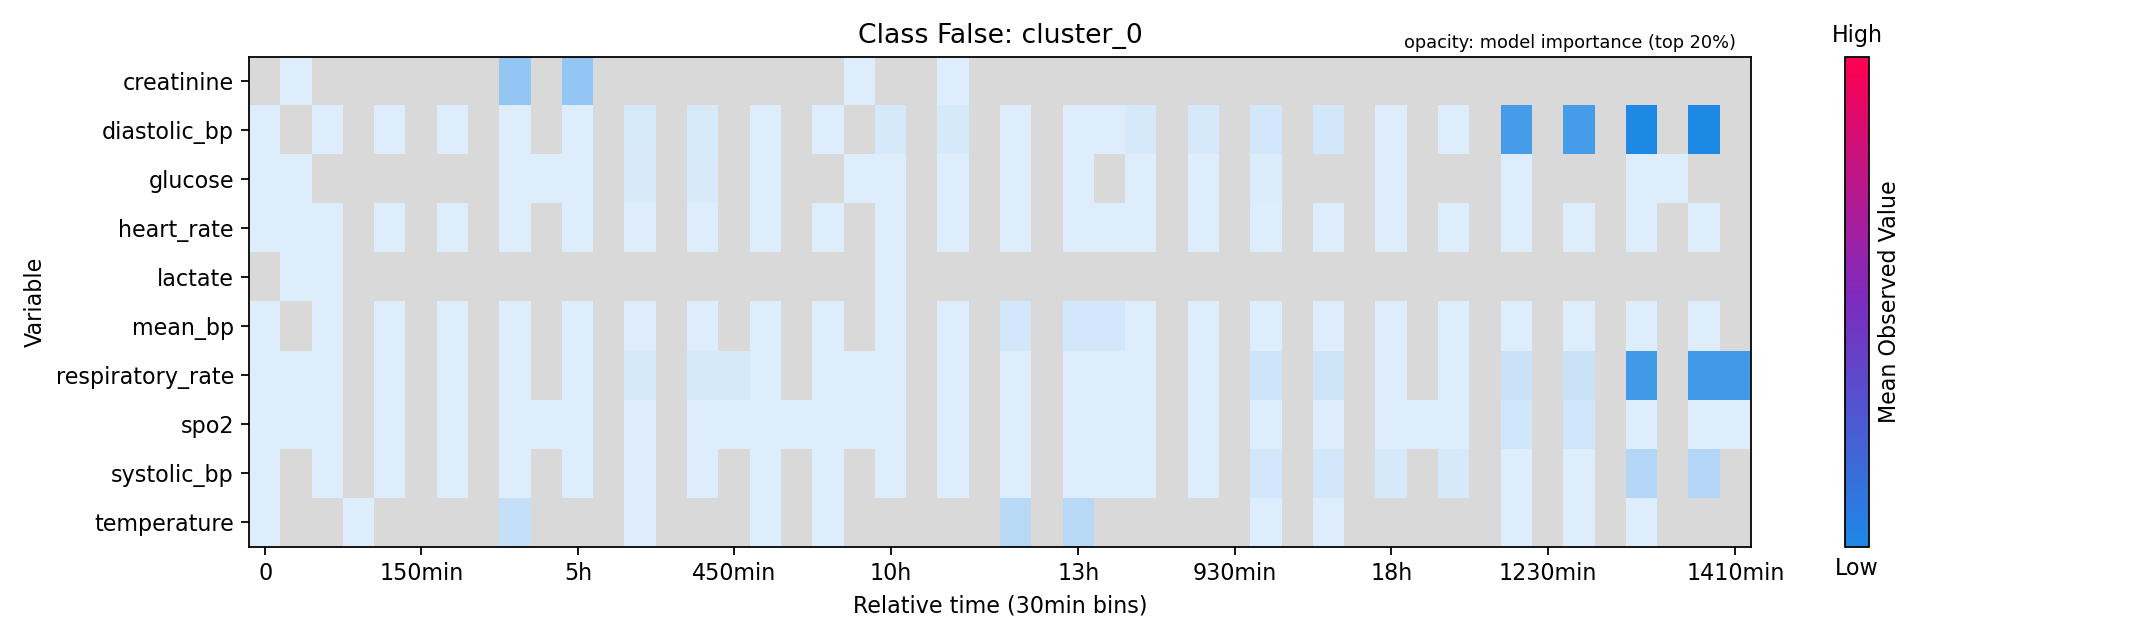

False/cluster_1.png


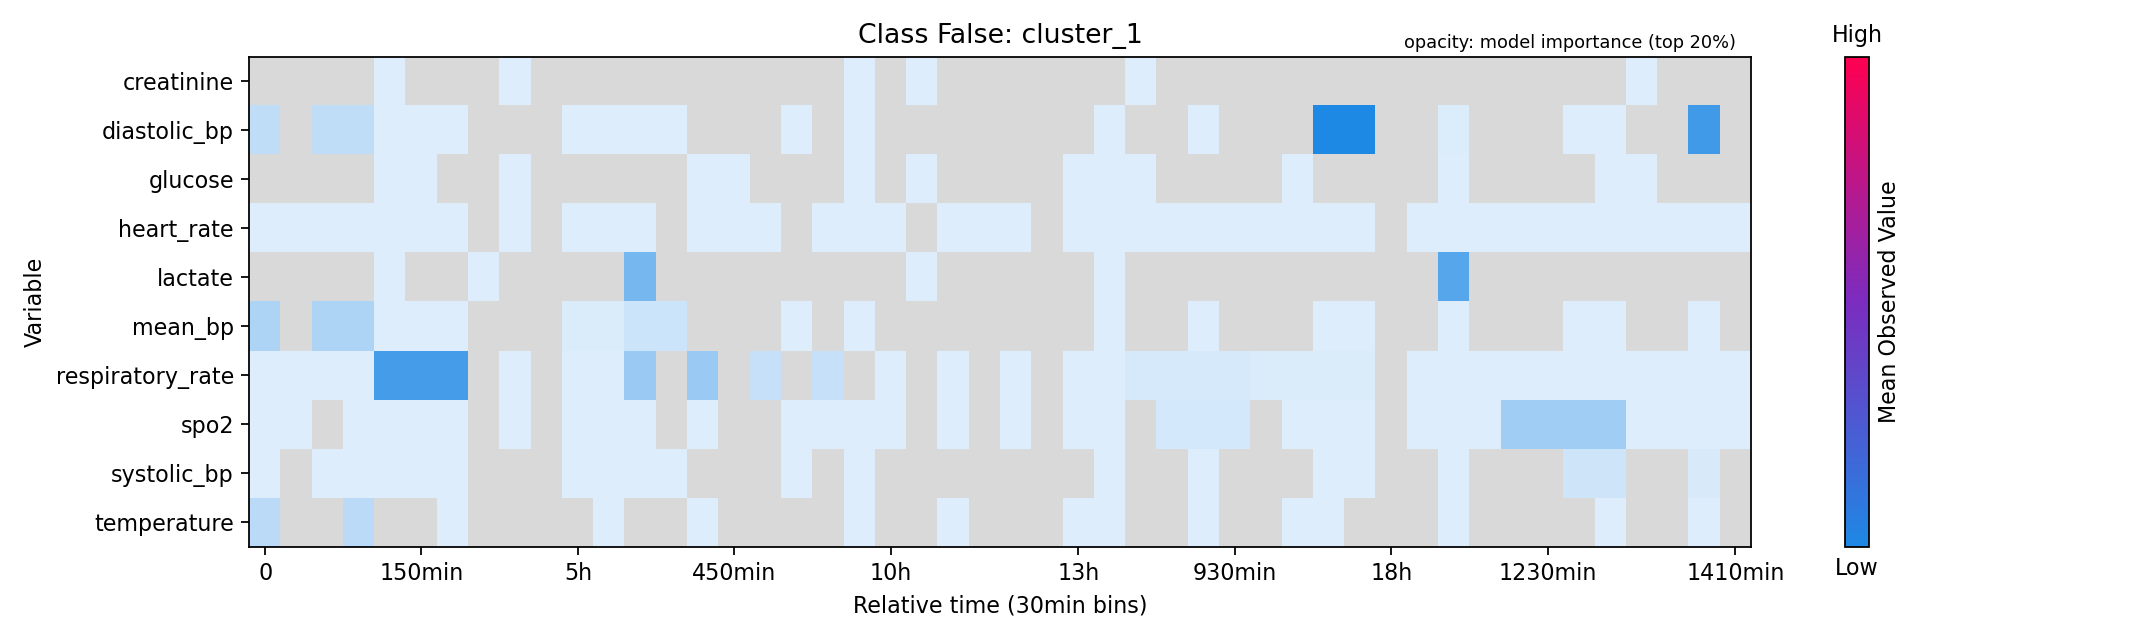

False/cluster_2.png


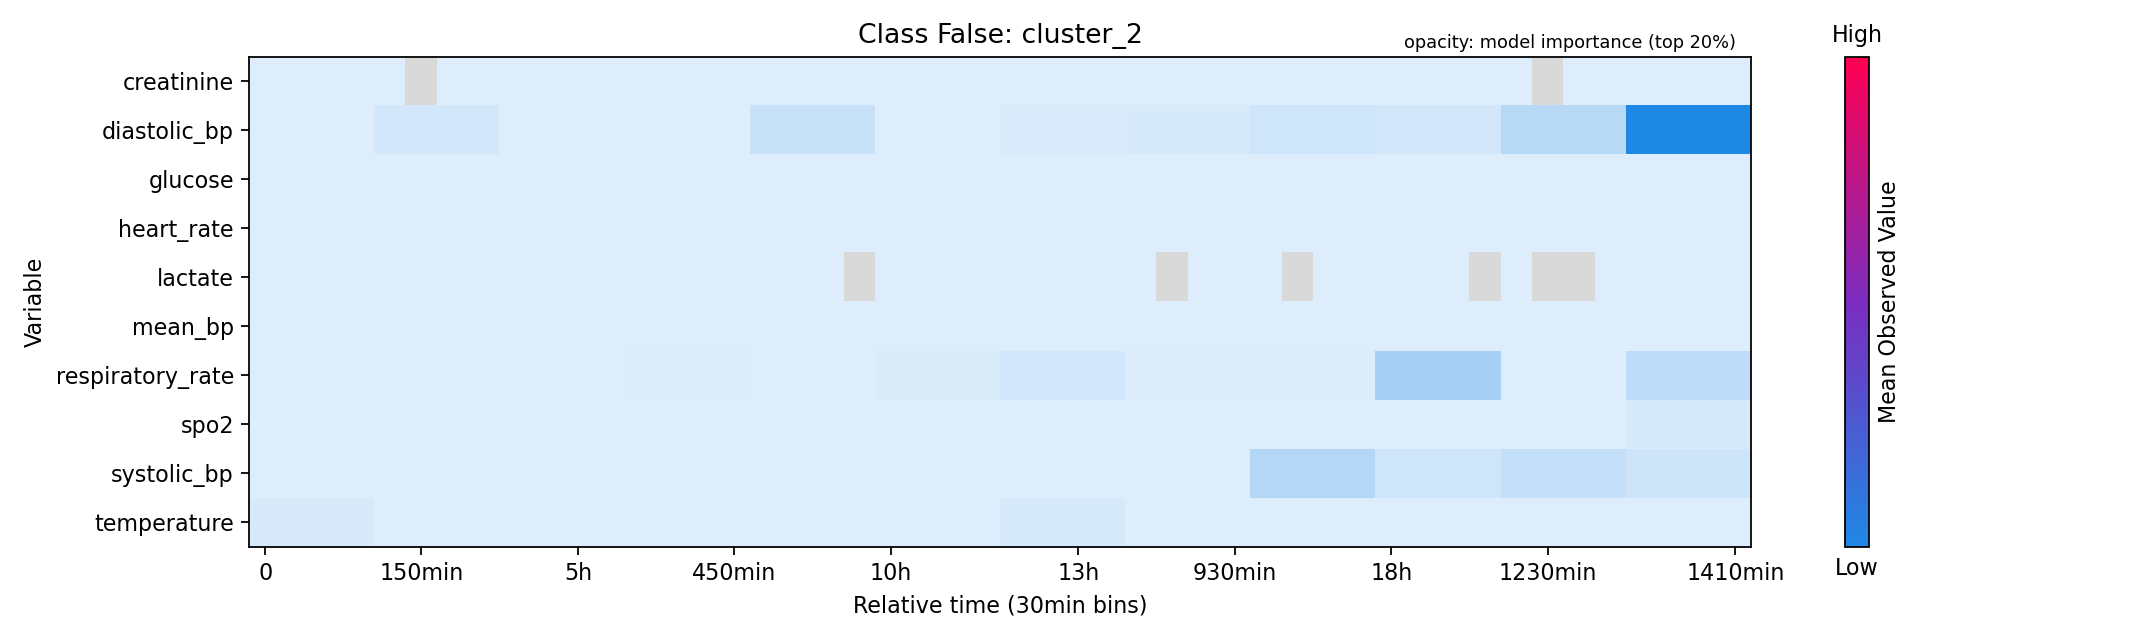

False/cluster_3.png


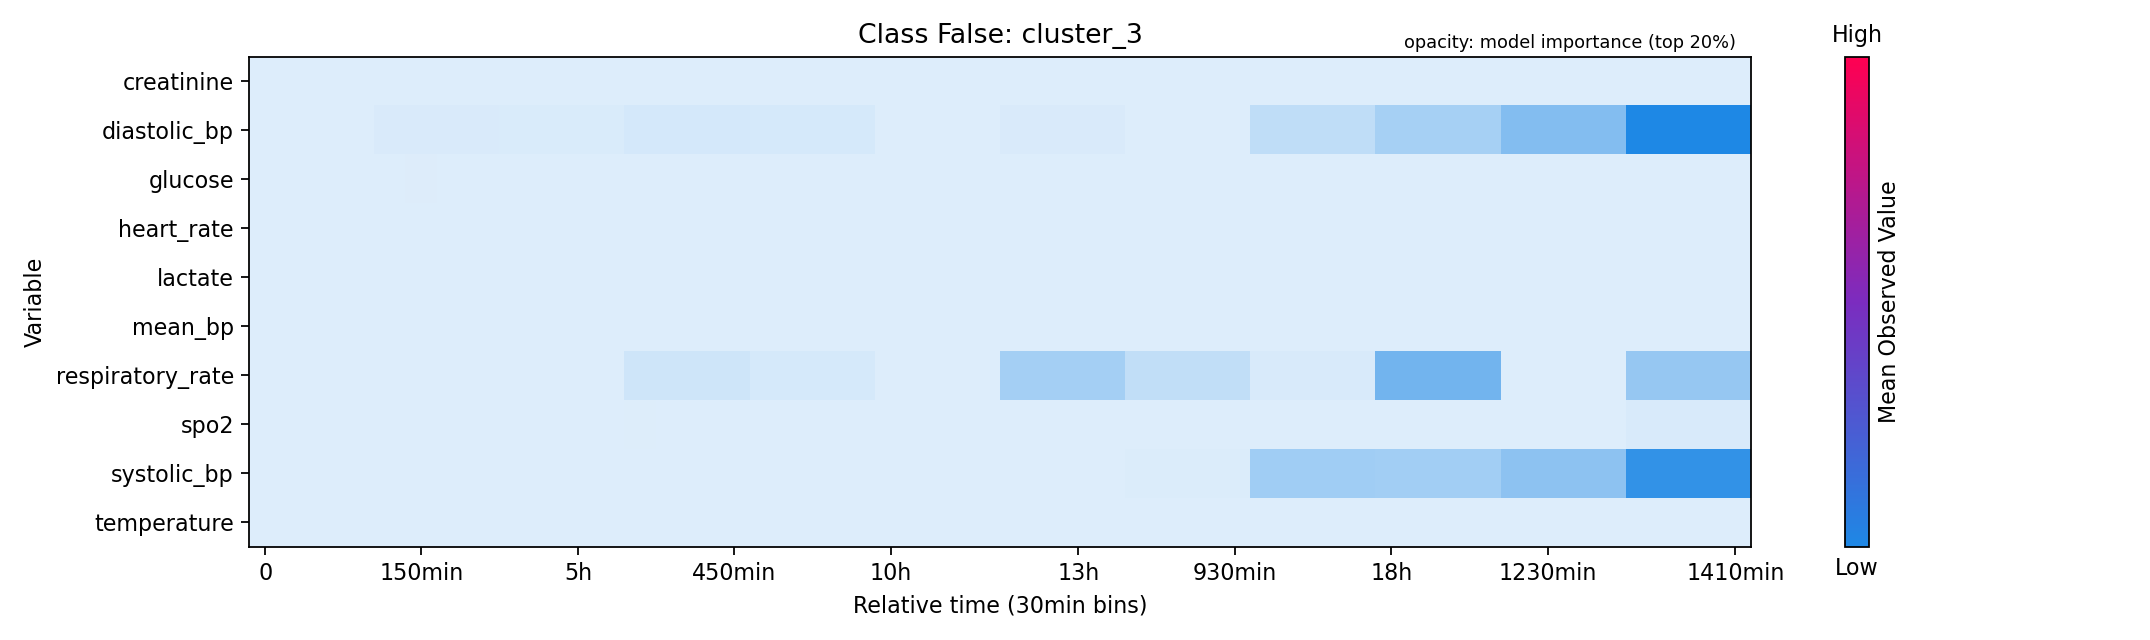

True/cluster_0.png


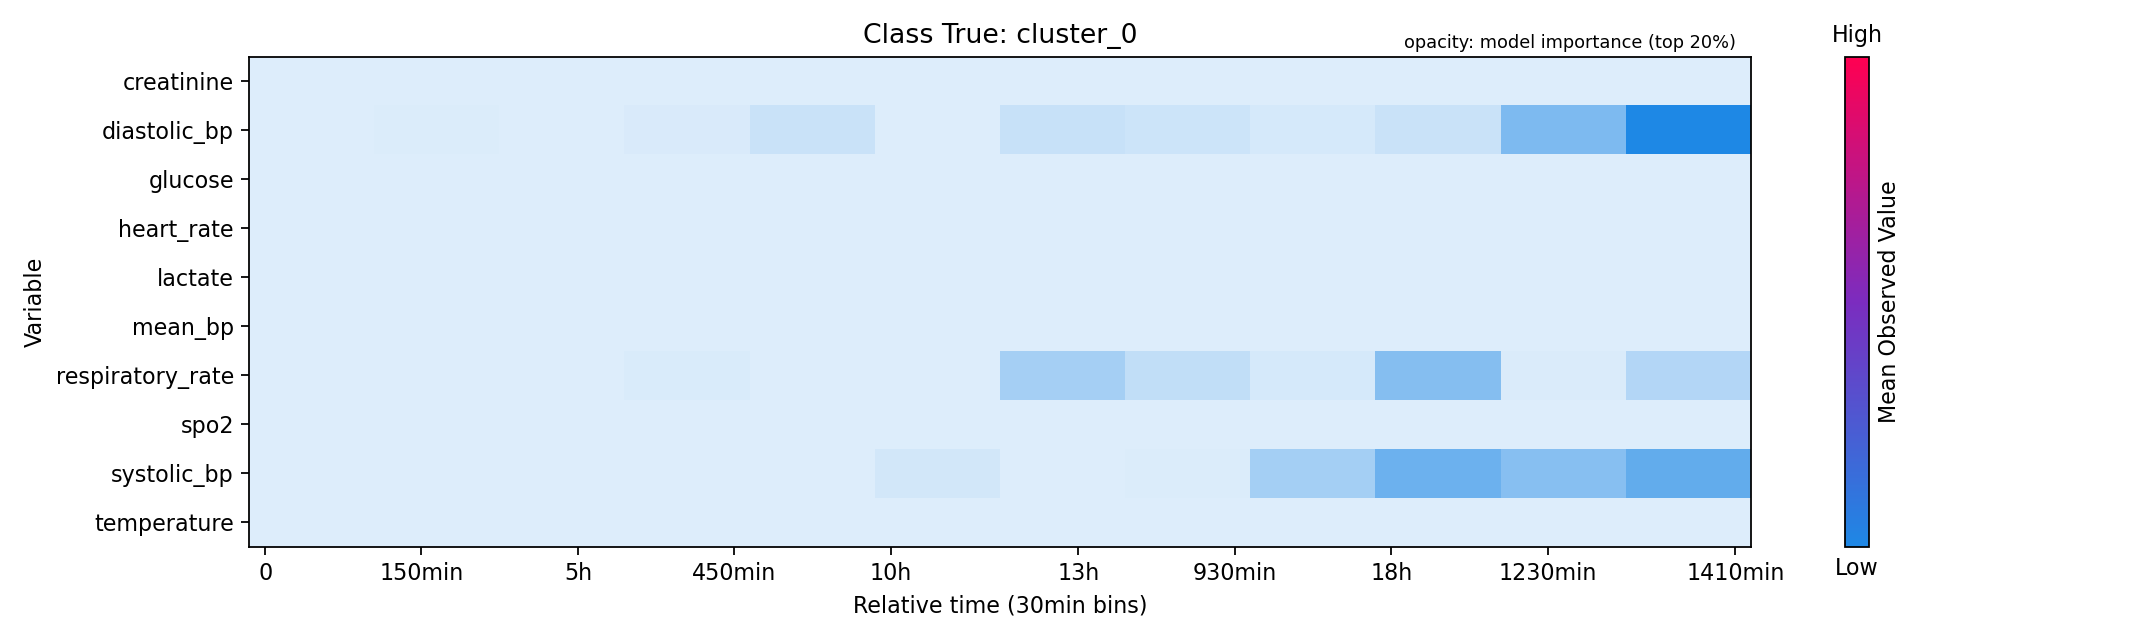

True/cluster_1.png


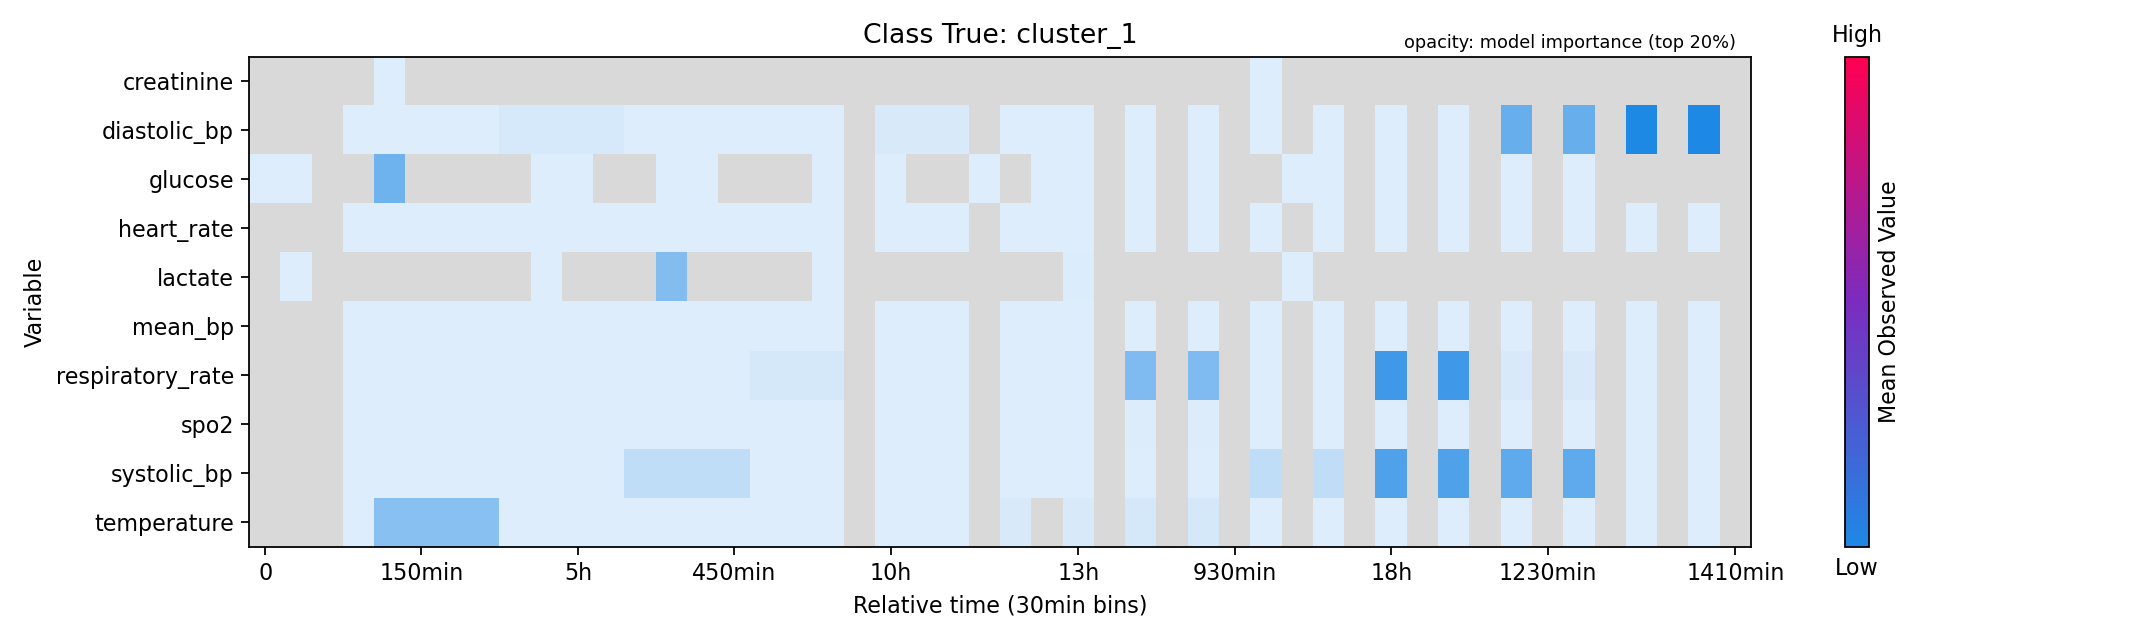

True/cluster_2.png


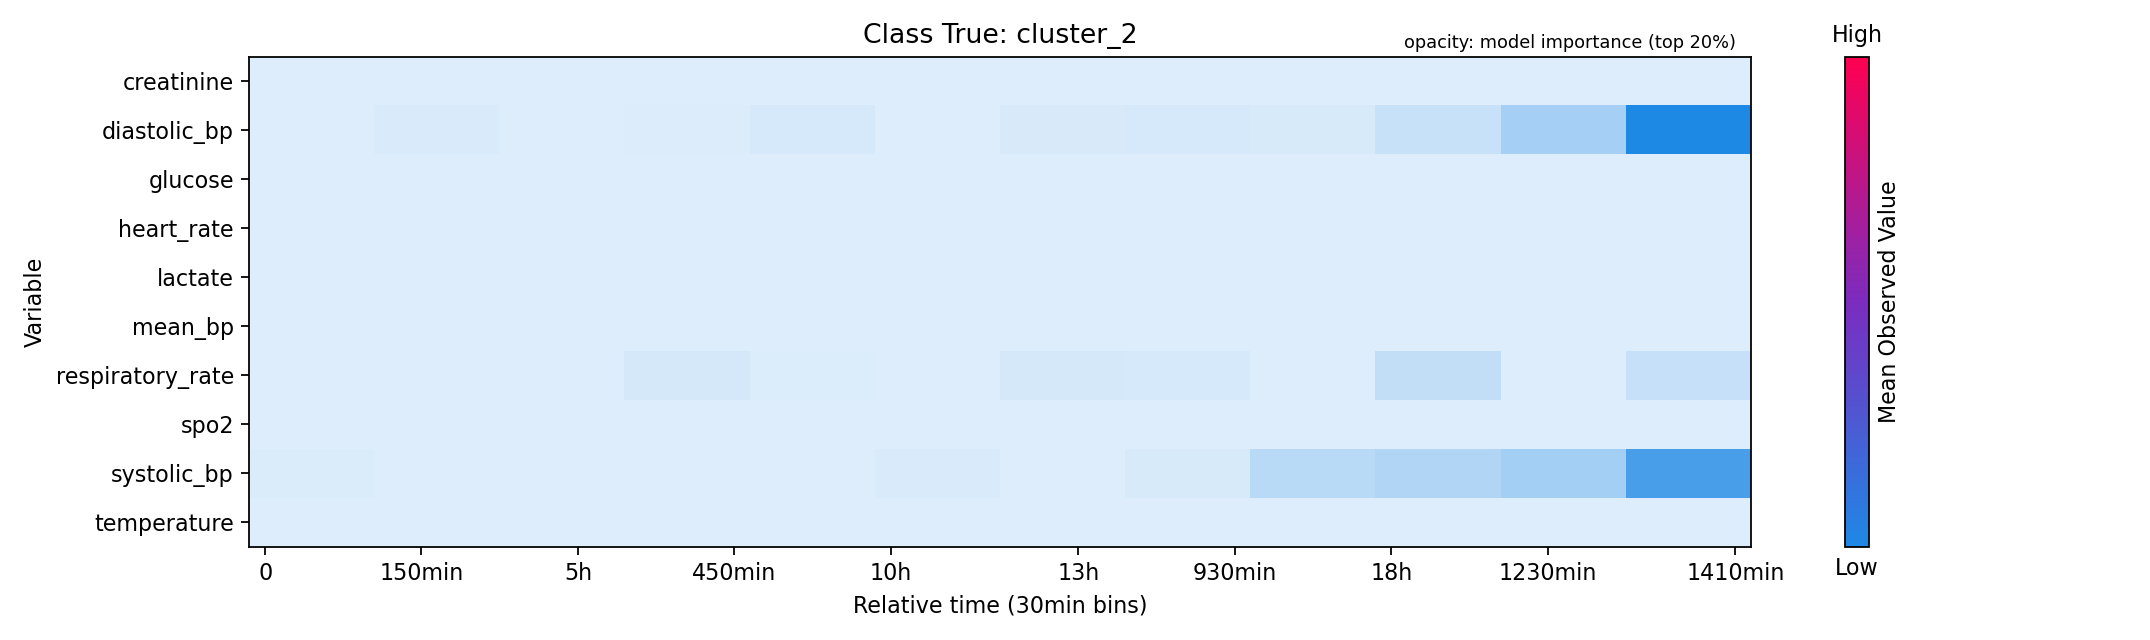

True/cluster_3.png


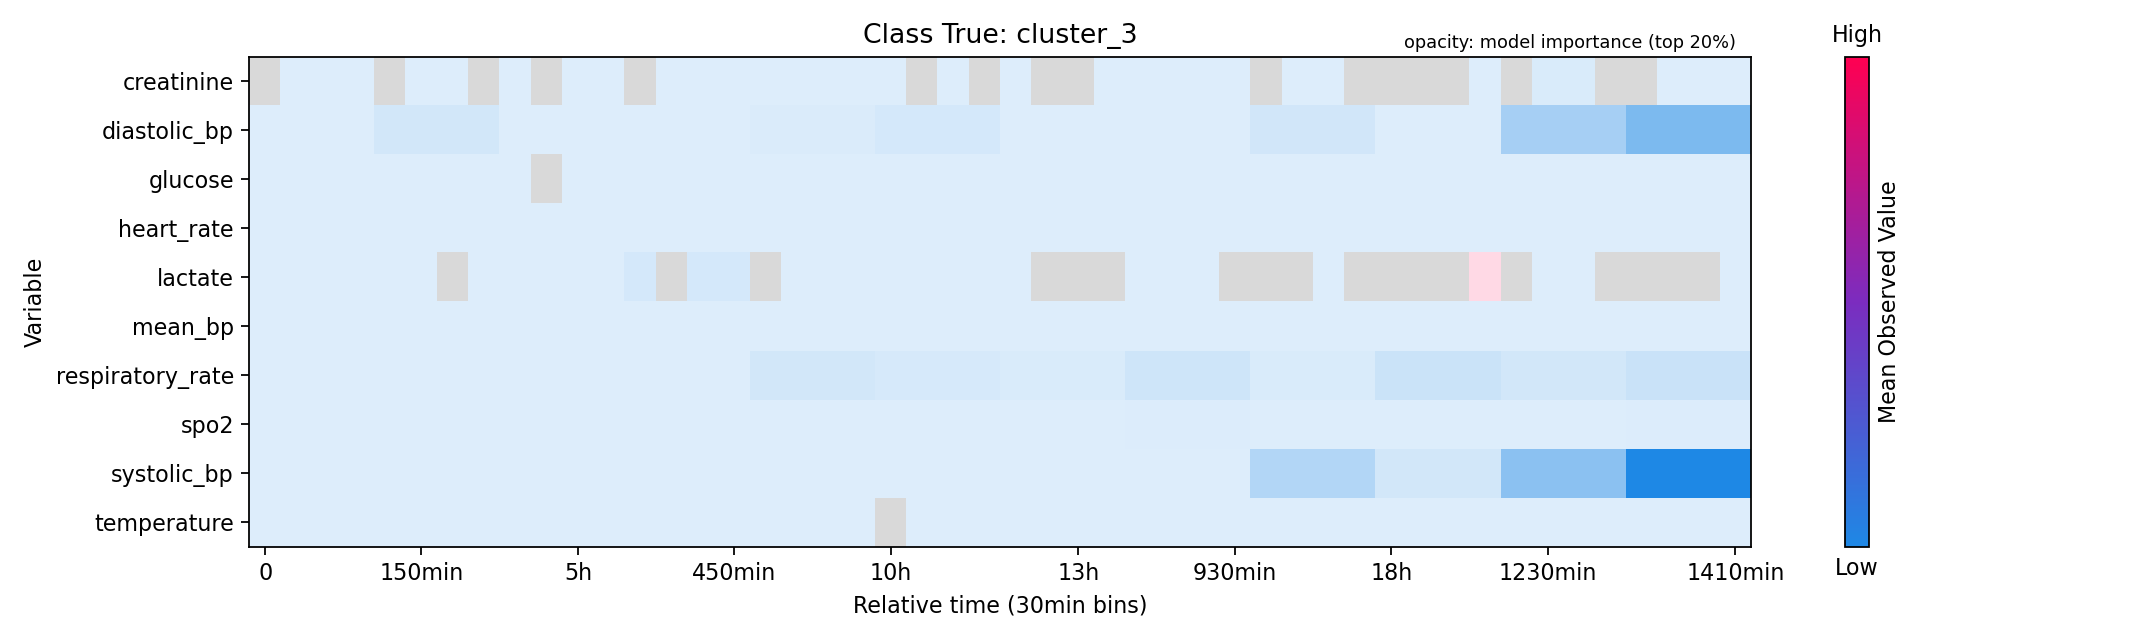

In [10]:
from IPython.display import Image, display

heatmap_dir = model.cluster_heatmaps_dir(EXPLANATION_SPLIT)
print('Cluster heatmaps:', heatmap_dir)
for heatmap in sorted(heatmap_dir.rglob('*.png')):
    print(heatmap.relative_to(heatmap_dir))
    display(Image(filename=str(heatmap)))

centroid_heatmap_dir = RUN_DIR / 'cluster_centroid_heatmaps' / EXPLANATION_SPLIT
if centroid_heatmap_dir.exists():
    print('Centroid representative heatmaps:', centroid_heatmap_dir)
    for heatmap in sorted(centroid_heatmap_dir.rglob('*.png')):
        print(heatmap.relative_to(centroid_heatmap_dir))
        display(Image(filename=str(heatmap)))



## 11. Compare Individual Patients

Use this section to compare single-patient clinical value trajectories across classes or within the same class. Values are shown only for cells whose explanation score passes `PATIENT_EXPLANATION_THRESHOLD`; the remaining cells render as gray.



In [ ]:
from IPython.display import Image, display

from interpretable_ts_vit.binning import TimeSeriesBinner
from interpretable_ts_vit.io import load_split
from interpretable_ts_vit.visualization import (
    load_normal_ranges,
    patient_class_frame,
    plot_patient_matrix_comparison,
    select_patient_ids,
)

PATIENTS_PER_COMPARISON_CLASS = 2
PATIENT_COMPARISON_RANDOM_STATE = None  # set an int to sample instead of taking the first patients
PATIENT_EXPLANATION_THRESHOLD = 0.8
PATIENT_EXPLANATION_THRESHOLD_MODE = 'quantile'  # 'quantile' for top cells, or 'absolute' for raw explanation scores
PATIENT_NORMAL_RANGES = load_normal_ranges() if USE_NORMAL_RANGES else None

patient_dataset = load_split(RUN_DIR / f'{EXPLANATION_SPLIT}.npz')
patient_binner = TimeSeriesBinner.load(RUN_DIR / 'binner.json')
predictions_path = model.predictions_path(EXPLANATION_SPLIT)
predictions = pd.read_csv(predictions_path, dtype={'patient_id': str}) if predictions_path.exists() else None
patient_frame = patient_class_frame(patient_dataset, patient_binner, predictions)

display(patient_frame.head())

positive_label = next(
    (label for label in patient_binner.index_to_label_ if str(label).lower() in {'true', '1', 'positive', 'case'}),
    patient_binner.index_to_label_[-1],
)
negative_label = next(
    (label for label in patient_binner.index_to_label_ if str(label) != str(positive_label)),
    None,
)

comparison_groups = {}
if predictions is not None:
    comparison_groups[f'predicted_{positive_label}'] = select_patient_ids(
        patient_dataset,
        patient_binner,
        predictions=predictions,
        predicted_label=str(positive_label),
        n=PATIENTS_PER_COMPARISON_CLASS,
        random_state=PATIENT_COMPARISON_RANDOM_STATE,
    )
    if negative_label is not None:
        comparison_groups[f'predicted_{negative_label}'] = select_patient_ids(
            patient_dataset,
            patient_binner,
            predictions=predictions,
            predicted_label=str(negative_label),
            n=PATIENTS_PER_COMPARISON_CLASS,
            random_state=PATIENT_COMPARISON_RANDOM_STATE,
        )

comparison_groups[f'true_{positive_label}'] = select_patient_ids(
    patient_dataset,
    patient_binner,
    true_label=str(positive_label),
    n=PATIENTS_PER_COMPARISON_CLASS,
    random_state=PATIENT_COMPARISON_RANDOM_STATE,
)

for group_name, patient_ids in comparison_groups.items():
    print(group_name, patient_ids)
    if not patient_ids:
        continue
    group_paths = plot_patient_matrix_comparison(
        patient_ids,
        patient_dataset,
        patient_binner,
        model.explanations_dir(EXPLANATION_SPLIT),
        RUN_DIR / 'patient_heatmaps' / EXPLANATION_SPLIT / group_name,
        show_values=SHOW_MEAN_VALUES,
        explanation_threshold=PATIENT_EXPLANATION_THRESHOLD,
        explanation_threshold_mode=PATIENT_EXPLANATION_THRESHOLD_MODE,
        plot_explanation=False,
        normal_ranges=PATIENT_NORMAL_RANGES,
    )
    for patient_id, patient_plot_paths in group_paths.items():
        print('Patient:', patient_id)
        image_path = patient_plot_paths['values']
        print('  values:', image_path)
        display(Image(filename=str(image_path)))





## 11. Inspect Saved Evaluation Artifacts

In [11]:
import json

metrics_path = model.metrics_path(SPLIT)
predictions_path = model.predictions_path(SPLIT)

if metrics_path.exists():
    print(json.dumps(json.loads(metrics_path.read_text()), indent=2))
if predictions_path.exists():
    display(pd.read_csv(predictions_path).head())

{
  "accuracy": 0.7659171597633136,
  "macro_f1": 0.7617918866522677,
  "confusion_matrix": [
    [
      5688,
      1532
    ],
    [
      1435,
      4020
    ]
  ],
  "auroc": 0.8449601245140927
}


,patient_id,predicted_label,prob_False,prob_True
0,30000831,True,0.444458,0.555542
1,30004391,False,0.778020,0.221980
2,30006118,False,0.879219,0.120781
3,30006565,False,0.706310,0.293690
4,30008528,True,0.456810,0.543190
